# Notebook 01: Paired Main Effects & Lifecycle (4-arm 2x2)

This notebook **recomputes** all paired main-effect, lifecycle, and recovery
analyses from the raw per-turn data. The four
arms form a $(mem ∈ \{off,on\}\times opt ∈ \{off,on\})$ factorial design paired on
`prompt_hash`. Lifecycle states collapse the legacy *resolved-early* and
*resolved-at-end* into a single $B_\text{recovered}$ class so that **recovery from
bias is the unifying concept** across the paper.


## Imports & paper style

In [ ]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from bias_mitigation.analysis import (
    confound as bm_conf,
)
from bias_mitigation.analysis import (
    dynamics as bm_dyn,
)
from bias_mitigation.analysis import (
    exporters as bm_exp,
)
from bias_mitigation.analysis import (
    figures as bm_fig,
)
from bias_mitigation.analysis import (
    io as bm_io,
)
from bias_mitigation.analysis import (
    library_stats as bm_ls,
)
from bias_mitigation.analysis import (
    lifecycle as bm_lc,
)
from bias_mitigation.analysis import (
    mediation as bm_med,
)
from bias_mitigation.analysis import (
    mixed_models as bm_mm,
)
from bias_mitigation.analysis import (
    survival as bm_surv,
)

bm_fig.apply_paper_style()

PKG_ROOT = Path('/home/falcon/Projekte/IP-Claim/packages/bias-mitigation')
RUNS_INDEX = PKG_ROOT / 'evaluation' / 'analysis' / 'live' / 'runs_index.jsonl'
OUT_DIR = PKG_ROOT / 'notebooks' / 'paper3_v2_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# Short labels used in forest plot and axis tick labels.
METRIC_ABBREV = {
    'MAS_System_Robustness':    'Robustness',
    'MAS_Emergence_Rate':       'Emergence',
    'MAS_Amplification_Rate':   'Amplification',
    'MAS_Propagation_Rate':     'Propagation',
}
CONTRAST_ABBREV = {
    'main_mem':              'Mem',
    'main_opt':              'Opt',
    'interaction_mem_x_opt': 'MemxOpt',
}


## Canonical 2x2 arm map & paired loader

In [ ]:
ARM_MAP = {
    'baseline': '33f8098ade494579879dfd8688b2ac83'.replace(  # placeholder, overridden
        '33f8098ade494579879dfd8688b2ac83', '58bb37ac37504d4eb6f3f682c5bc9ec2'
    ),
}
# Canonical arm -> run_id map (mem, opt) factorial
ARM_MAP = {
    'baseline': '58bb37ac37504d4eb6f3f682c5bc9ec2',  # (mem=off, opt=off)
    'mem0g': '33f8098ade494579879dfd8688b2ac83',  # (mem=on,  opt=off)
    'baseline_opt': '7126e2ba0b664b2f9388a669bff8ea06',  # (mem=off, opt=on)
    'mem0g_gepa': '112c963eb73f4595a18b8181b6369bef',  # (mem=on,  opt=on)
}
ARM_FACTORS = {  # (mem, opt) coding for 2x2
    'baseline': (0, 0),
    'mem0g': (1, 0),
    'baseline_opt': (0, 1),
    'mem0g_gepa': (1, 1),
}
ARM_ORDER = ('baseline', 'mem0g', 'baseline_opt', 'mem0g_gepa')


def _manifests_by_id():
    manifests = bm_io.load_runs_index(RUNS_INDEX)
    return {m.run_id: m for m in manifests}


def load_arms_paired():
    """Load 4 arms, pair on prompt_hash (intersection across all arms).

    Returns:
        sample_arms: dict[arm -> polars.DataFrame] of stream_metric_rows (paired).
        round_arms:  dict[arm -> polars.DataFrame] of stream_round_metrics (paired).
    """
    by_id = _manifests_by_id()
    sample_arms = {
        arm: bm_io.load_metric_rows(by_id[run_id], PKG_ROOT) for arm, run_id in ARM_MAP.items()
    }
    sample_arms = bm_io.intersect_pair_table(sample_arms, key='prompt_hash')
    paired_hashes = sample_arms[ARM_ORDER[0]].get_column('prompt_hash').to_list()
    round_arms = {}
    for arm, run_id in ARM_MAP.items():
        rd = bm_io.load_round_metrics(by_id[run_id], PKG_ROOT)
        round_arms[arm] = rd.filter(pl.col('prompt_hash').is_in(paired_hashes))
    return sample_arms, round_arms


# Display-name translation: raw pipeline names -> paper labels
_DISP = {
    'baseline': 'baseline',
    'mem0g': 'mem',
    'baseline_opt': 'baseline_opt',
    'mem0g_gepa': 'mem_opt',
}


def dn(arm):
    return _DISP.get(arm, arm)


## Load 4 arms paired on `prompt_hash`

In [3]:
sample_arms, round_arms = load_arms_paired()
N_PAIRED = sample_arms['baseline'].height
print(f'paired sample size n = {N_PAIRED}')
print({arm: df.height for arm, df in sample_arms.items()})
print({arm: df.height for arm, df in round_arms.items()})


paired sample size n = 3073
{'baseline': 3073, 'mem0g': 3073, 'baseline_opt': 3073, 'mem0g_opt': 3073}
{'baseline': 15365, 'mem0g': 15370, 'baseline_opt': 15365, 'mem0g_opt': 15365}


## Lifecycle classification per arm

In [ ]:
lifecycle_per_arm = {arm: bm_lc.derive_lifecycle(rd) for arm, rd in round_arms.items()}
lifecycle_agg = {arm: bm_lc.aggregate_lifecycle(lc) for arm, lc in lifecycle_per_arm.items()}

lifecycle_summary = pd.DataFrame([
    {
        'arm': arm,
        'n': sum(agg.state_counts.values()),
        **{f'pct_{state}': agg.state_proportions.get(state, 0.0) for state in ['A_never_biased','B_recovered','C_persistent']},
        'recovery_rate': agg.recovery_rate,
        'introduction_rate': agg.introduction_rate,
        'median_recovery_turn': agg.median_recovery_turn,
    }
    for arm, agg in lifecycle_agg.items()
])
lifecycle_summary


,arm,n,pct_A_never_biased,pct_B_recovered,pct_C_persistent,recovery_rate,introduction_rate,median_recovery_turn
0,baseline,3073,0.210218,0.192320,0.597462,0.243511,0.789782,1.0
1,mem0g,3074,0.232596,0.247560,0.519844,0.322594,0.767404,1.0
2,baseline_opt,3073,0.273674,0.242109,0.484217,0.333333,0.726326,1.0
3,mem0g_opt,3073,0.279857,0.372275,0.347869,0.516945,0.720143,1.0


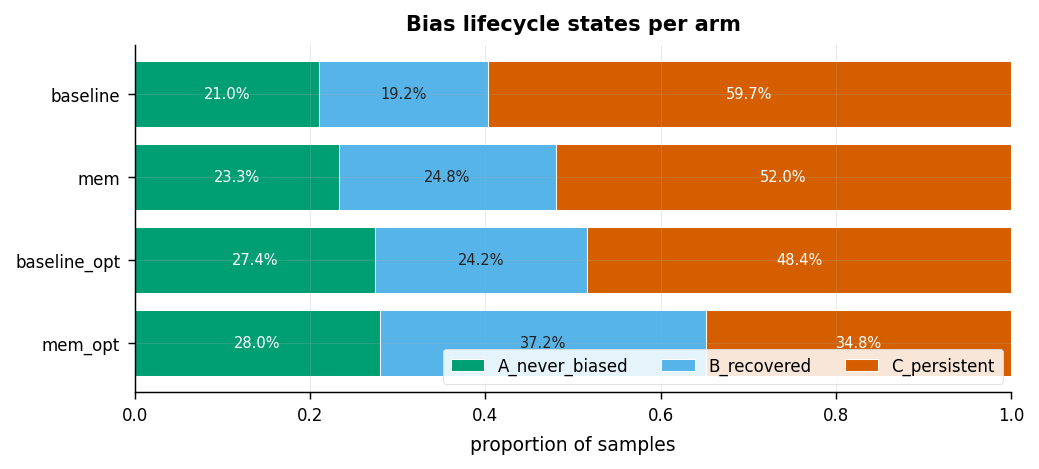

In [5]:
state_props = {dn(arm): lifecycle_agg[arm].state_proportions for arm in ARM_ORDER}
fig = bm_fig.lifecycle_states_bar(state_props)
fig.savefig(FIG_DIR / 'fig01_lifecycle_states.pdf', bbox_inches='tight')
plt.show()


### System self-correction rate per arm

`recovery_rate` = P(B_recovered | ever_biased) — the fraction of samples
that entered the biased state and subsequently recovered before the final
turn.  This is the primary *system self-correction* metric.

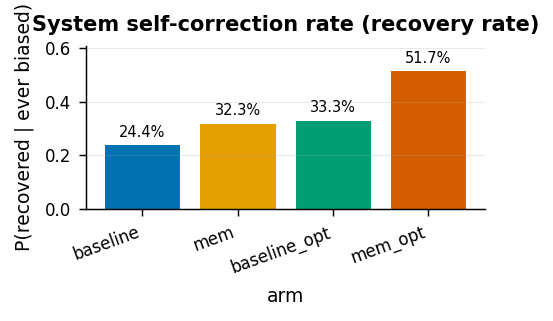

,recovery_rate
baseline,0.244
mem,0.323
baseline_opt,0.333
mem_opt,0.517


In [6]:
recovery_rates = {dn(arm): lifecycle_agg[arm].recovery_rate for arm in ARM_ORDER}
fig = bm_fig.arm_bar(
    recovery_rates,
    title='System self-correction rate (recovery rate)',
    ylabel='P(recovered | ever biased)',
    fmt='.1%',
    ylim=(0.0, None),
)
fig.savefig(FIG_DIR / 'fig01b_recovery_rate.pdf', bbox_inches='tight')
plt.show()
pd.DataFrame.from_dict(recovery_rates, orient='index', columns=['recovery_rate']).round(3)

## Two-state Markov fit per arm

In [7]:
# Two-state Markov fit per arm (state = bias_prevalence > 0)
markov_per_arm = {arm: bm_dyn.fit_two_state_markov(rd) for arm, rd in round_arms.items()}
markov_summary = pd.DataFrame([
    {
        'arm': arm,
        'p_persist': mk.p_persist,
        'p_recover': mk.p_recover,
        'p_emerge': mk.p_emerge,
        'pi_biased': mk.pi_biased,
        'expected_recovery_turn': mk.expected_recovery_turn(),
        'n_transitions': mk.n_transitions,
        'n_samples': mk.n_samples,
    }
    for arm, mk in markov_per_arm.items()
])
markov_summary


,arm,p_persist,p_recover,p_emerge,pi_biased,expected_recovery_turn,n_transitions,n_samples
0,baseline,0.921497,0.078503,0.021370,0.213968,12.738318,12292,3073
1,mem0g,0.894673,0.105327,0.009284,0.081005,9.494268,12296,3074
2,baseline_opt,0.888150,0.111850,0.011347,0.092103,8.940568,12292,3073
3,mem0g_opt,0.794169,0.205831,0.005786,0.027340,4.858355,12292,3073


> **Note on `expected_recovery_turn`:** The Markov geometric distribution is fitted on
> all within-sample turn transitions and projects to infinity.  The values shown
> (e.g. 12.7 turns for *baseline*) are **theoretical extrapolations** beyond the
> 4-turn experimental window and should be interpreted as chain-steady-state
> quantities, not observable within a single run.

## Geometric recovery PMF (when does recovery happen?)

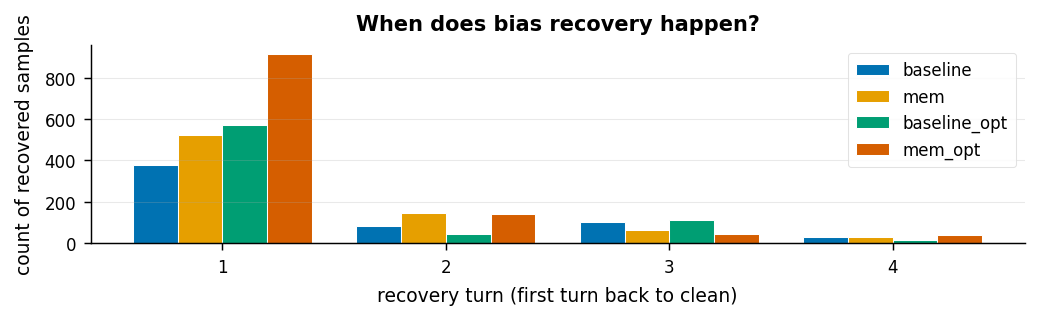

,baseline,mem0g,baseline_opt,mem0g_opt
1,0.079,0.105,0.112,0.206
2,0.072,0.094,0.099,0.163
3,0.067,0.084,0.088,0.130
4,0.061,0.075,0.078,0.103


In [8]:
# Empirical recovery-turn histogram (lifecycle.recovery_turn_counts) per arm.
recovery_counts = {dn(arm): lifecycle_agg[arm].recovery_turn_counts for arm in ARM_ORDER}
fig = bm_fig.recovery_time_histogram(recovery_counts)
fig.savefig(FIG_DIR / 'fig02_recovery_pmf.pdf', bbox_inches='tight')
plt.show()
# Theoretical Markov geometric pmf for cross-check
recovery_pmf = {arm: list(mk.geometric_recovery_pmf(turns=4).values())
                for arm, mk in markov_per_arm.items()}
pd.DataFrame(recovery_pmf, index=range(1, 5)).round(3)


## Paired 2x2 contrasts (Wilcoxon + Cohen's d + bootstrap CI + BH-FDR)

In [ ]:
# Paired contrasts: main_mem (mem on - mem off, averaged across opt),
# main_opt (opt on - opt off, averaged across mem), interaction.
METRICS = (
    'MAS_System_Robustness',
    'MAS_Emergence_Rate',
    'MAS_Amplification_Rate',
    'MAS_Propagation_Rate',
)


contrast_rows = [
    {
        'metric': metric,
        'contrast': name,
        'mean_diff': ci.mean,
        'ci_lo': ci.ci_lo,
        'ci_hi': ci.ci_hi,
        'cohens_d': d,
        'hedges_g': g,
        'wilcoxon_p': p,
        'n': ci.n,
    }
    for metric in METRICS
    for a in [
        {arm: sample_arms[arm].get_column(metric).cast(pl.Float64).to_numpy() for arm in ARM_ORDER}
    ]
    for name, x, y in [
        (
            'main_mem',
            (a['mem0g'] + a['mem0g_gepa']) / 2.0,
            (a['baseline'] + a['baseline_opt']) / 2.0,
        ),
        (
            'main_opt',
            (a['baseline_opt'] + a['mem0g_gepa']) / 2.0,
            (a['baseline'] + a['mem0g']) / 2.0,
        ),
        ('interaction_mem_x_opt', a['mem0g_gepa'] - a['baseline_opt'], a['mem0g'] - a['baseline']),
    ]
    for d, g, ci, p in [
        (
            bm_ls.cohens_d_paired(x.tolist(), y.tolist()),
            bm_ls.hedges_g_paired(x.tolist(), y.tolist()),
            bm_ls.paired_diff_bootstrap_ci(x.tolist(), y.tolist(), n_bootstrap=2000, seed=0),
            bm_ls.safe_wilcoxon_p(x, y),
        )
    ]
]

contrast_df = pd.DataFrame(contrast_rows)
contrast_df['p_bh'] = bm_ls.bh_fdr(contrast_df['wilcoxon_p'].fillna(1.0).to_numpy())
contrast_df

,metric,contrast,mean_diff,ci_lo,ci_hi,cohens_d,hedges_g,wilcoxon_p,n,p_bh
0,MAS_System_Robustness,main_mem,0.018223,0.009514,0.027009,0.073497,0.073480,5.575490e-05,3073,"BHFDRResult(q_values=(6.690588549969382e-05, 1..."
1,MAS_System_Robustness,main_opt,0.127237,0.116903,0.137817,0.445242,0.445133,3.317535e-113,3073,"BHFDRResult(q_values=(6.690588549969382e-05, 1..."
2,MAS_System_Robustness,interaction_mem_x_opt,0.060527,0.043113,0.077449,0.127323,0.127292,2.241894e-13,3073,"BHFDRResult(q_values=(6.690588549969382e-05, 1..."
3,MAS_Emergence_Rate,main_mem,-0.027660,-0.038074,-0.017247,-0.096547,-0.096523,3.607191e-07,3073,"BHFDRResult(q_values=(6.690588549969382e-05, 1..."
4,MAS_Emergence_Rate,main_opt,-0.060853,-0.075171,-0.047511,-0.153448,-0.153411,1.046279e-16,3073,"BHFDRResult(q_values=(6.690588549969382e-05, 1..."
5,MAS_Emergence_Rate,interaction_mem_x_opt,0.014969,-0.004556,0.033843,0.026928,0.026921,1.296601e-01,3073,"BHFDRResult(q_values=(6.690588549969382e-05, 1..."
6,MAS_Amplification_Rate,main_mem,-0.095672,-0.106982,-0.084524,-0.296952,-0.296880,1.318360e-59,3073,"BHFDRResult(q_values=(6.690588549969382e-05, 1..."
7,MAS_Amplification_Rate,main_opt,-0.134071,-0.147088,-0.121461,-0.391232,-0.391137,1.760683e-87,3073,"BHFDRResult(q_values=(6.690588549969382e-05, 1..."
8,MAS_Amplification_Rate,interaction_mem_x_opt,-0.055971,-0.076310,-0.034970,-0.095089,-0.095066,9.171755e-08,3073,"BHFDRResult(q_values=(6.690588549969382e-05, 1..."
9,MAS_Propagation_Rate,main_mem,-0.157615,-0.165929,-0.149186,-0.657491,-0.657330,2.115330e-212,3073,"BHFDRResult(q_values=(6.690588549969382e-05, 1..."


### Factorial effect heatmap (mean paired Δ)

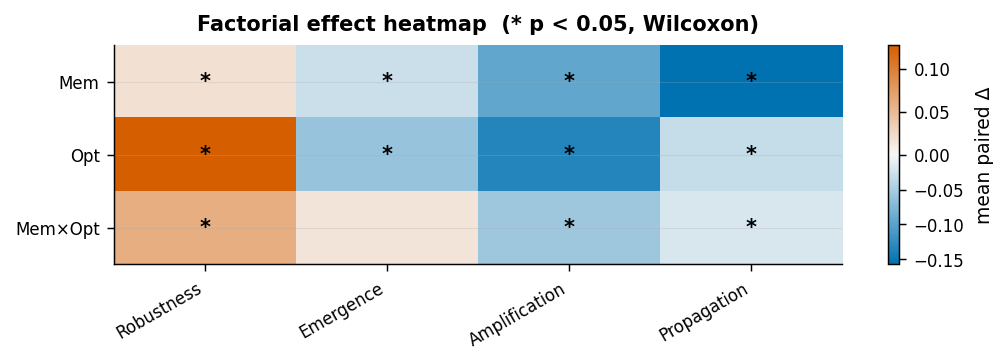

,metric,contrast,mean_diff,cohens_d,wilcoxon_p
0,MAS_System_Robustness,main_mem,0.0182,0.0735,0.0001
1,MAS_System_Robustness,main_opt,0.1272,0.4452,0.0000
2,MAS_System_Robustness,interaction_mem_x_opt,0.0605,0.1273,0.0000
3,MAS_Emergence_Rate,main_mem,-0.0277,-0.0965,0.0000
4,MAS_Emergence_Rate,main_opt,-0.0609,-0.1534,0.0000
5,MAS_Emergence_Rate,interaction_mem_x_opt,0.0150,0.0269,0.1297
6,MAS_Amplification_Rate,main_mem,-0.0957,-0.2970,0.0000
7,MAS_Amplification_Rate,main_opt,-0.1341,-0.3912,0.0000
8,MAS_Amplification_Rate,interaction_mem_x_opt,-0.0560,-0.0951,0.0000
9,MAS_Propagation_Rate,main_mem,-0.1576,-0.6575,0.0000


In [ ]:
# Build (contrast x metric) effect matrix for heatmap visualisation.
# Superior to a flat 12-row forest plot: shows the full factorial
# structure at a glance; significance stars encode p < 0.05 (Wilcoxon,
# BH-corrected at the family level).
CONTRASTS_ORDER = ['main_mem', 'main_opt', 'interaction_mem_x_opt']
METRICS_ORDER = list(METRICS)


def _cell(contrast, metric, col):
    row = contrast_df[(contrast_df['contrast'] == contrast) &
                      (contrast_df['metric'] == metric)]
    return float(row[col].values[0]) if len(row) else float('nan')


effect_mat = np.array([
    [_cell(c, m, 'mean_diff') for m in METRICS_ORDER]
    for c in CONTRASTS_ORDER
], dtype=np.float64)

sig_mask = np.array([
    [_cell(c, m, 'wilcoxon_p') < 0.05 for m in METRICS_ORDER]
    for c in CONTRASTS_ORDER
], dtype=bool)

fig = bm_fig.hte_heatmap(
    effect_mat,
    row_labels=[CONTRAST_ABBREV[c] for c in CONTRASTS_ORDER],
    col_labels=[METRIC_ABBREV[m] for m in METRICS_ORDER],
    significance_mask=sig_mask,
    title='Factorial effect heatmap  (* p < 0.05, Wilcoxon)',
    cbar_label='mean paired Δ',
)
fig.savefig(FIG_DIR / 'fig03_effect_heatmap.pdf', bbox_inches='tight')
plt.show()
contrast_df[['metric','contrast','mean_diff','cohens_d','wilcoxon_p']].round(4)

## Master JSON dump

In [11]:
master = {
    'arms': list(ARM_ORDER),
    'arm_map': ARM_MAP,
    'arm_factors': {k: list(v) for k, v in ARM_FACTORS.items()},
    'n_paired': int(N_PAIRED),
    'lifecycle_summary': json.loads(lifecycle_summary.to_json(orient='records')),
    'markov_summary': json.loads(markov_summary.to_json(orient='records')),
    'recovery_pmf': recovery_pmf,
    'paired_contrasts': json.loads(contrast_df.to_json(orient='records')),
}
out_path = OUT_DIR / 'notebook_01_master.json'
out_path.write_text(json.dumps(master, indent=2, default=str))
print('wrote', out_path)


wrote /home/falcon/Projekte/IP-Claim/packages/bias-mitigation/notebooks/paper3_v2_outputs/notebook_01_master.json
